In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import spikeinterface.full as si
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
si.set_global_job_kwargs(n_jobs=0.8, pool_engine='process', progress_bar=True)
# si.set_global_job_kwargs(n_jobs=1, pool_engine='process')
from spikeinterface.benchmark.benchmark_plot_tools import despine, clean_axis

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

from configuration import figure_folder

In [3]:
myparams = {
    'axes.titlesize' : 12,
    'axes.labelsize' : 10,
    'lines.linewidth' : 2,
    'lines.markersize' : 10,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10
}

In [4]:
from configuration import base_path
from dataset import get_dataset
# dataset_name = 'Neuropixels1-384_500_600.s'
# dataset_name = 'Neuropixels1-128_250_100.s'
# dataset_name = 'Neuropixels1-384_500_600.s'
dataset_name = 'Neuropixels1-384_500_1800.s'


seed = 2205
# seed = None

rec_static, rec_drifting, gt_sorting, analyzer_static, \
    analyzer_drifting, extra_infos = get_dataset(dataset_name, with_extra_info=True, seed=seed)


In [5]:
rec = rec_static


# PLot motion

In [6]:
extra_infos.keys()

dict_keys(['displacement_vectors', 'displacement_sampling_frequency', 'unit_locations', 'displacement_unit_factor', 'unit_displacements', 'templates', 'generate_templates_kwargs'])

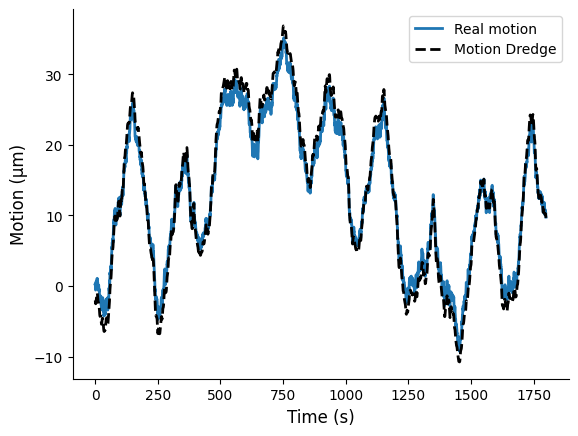

In [18]:

def plot_motion_dataset(ax):
    from spikeinterface.benchmark.benchmark_motion_estimation import get_gt_motion_from_unit_displacement

    rec = rec_static
    channel_locations = rec.get_channel_locations()
    duration = rec.get_duration()


    bin_s = 0.5
    temporal_bins_s = np.arange(0, duration, bin_s)
    spatial_bins_um = np.linspace(np.min(channel_locations[:, 1]), np.max(channel_locations[:, 1]), 4)


    gt_motion = get_gt_motion_from_unit_displacement(
        extra_infos["unit_displacements"],
        extra_infos["displacement_sampling_frequency"],
        extra_infos["unit_locations"],
        temporal_bins_s,
        spatial_bins_um,
        direction_dim=1,
    )
    displacement = gt_motion.displacement[0]
    ax.plot(temporal_bins_s, np.mean(displacement, axis=1), color="C0", label='Real motion')


    global_name = 'clustering_drifting'
    motion_folder = base_path / global_name / dataset_name / 'motion'
    motion_info = motion = si.load_motion_info(motion_folder)
    motion = motion_info['motion']

    temporal_bins_s = motion.temporal_bins_s[0]
    offset = np.median(gt_motion.displacement[0][:, :]) - np.median(motion.displacement[0][:, :])
    displacement = motion.displacement[0] + offset
    ax.plot(temporal_bins_s, np.mean(displacement, axis=1), color="#000000", ls='--', label='Motion Dredge')




    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Motion (µm)')
    ax.legend()
    despine(ax)

with mpl.rc_context(myparams):
    fig, ax= plt.subplots()
    plot_motion_dataset(ax)

# plot unit locs

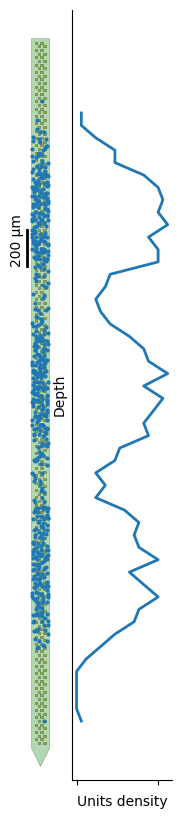

In [8]:
# %matplotlib ipympl


def plot_unit_locs_dist(ax1, ax2):

    x = extra_infos["unit_locations"][:, 0]
    y = extra_infos["unit_locations"][:, 1]
    # fig, axs = plt.subplots(ncols=2, sharey=True)


    ax1.set_xticklabels([])


    si.plot_probe_map(rec, ax=ax1)
    ax1.scatter(x, y, s=4, color='C0')
    ax1.set_xlabel('')
    ax1.set_ylabel('')

    count, bins = np.histogram(y, bins=50, density=True)
    ax2.plot(count, bins[:-1], color='C0')
    ax2.set_xlabel('Units density')
    ax2.set_ylabel('Depth')

    # ax2.sharey(ax1)
    # ax2.set_yticklabels([])
    ax2.set_xticklabels([])


    ax2.sharey(ax1)
    ax1.set_ylim(-200 , 4_000)
    # ax1.set_xlim(-150 , 120)
    # ax2.set_ylim(-200 , 4_000)
    
    clean_axis(ax1)
    # clean_axis(ax2)
    despine(ax2)

    # despine(ax1)
    # despine(ax2)

    ax1.plot([-50, -50], [2600, 2800], color='k')
    ax1.text(-140, 2612, '200 μm', rotation=90)


with mpl.rc_context(myparams):
    fig = plt.figure(figsize=(2,10))
    gs = GridSpec(1, 3)
    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[0,1:])
    plot_unit_locs_dist(ax1, ax2)




# plot firing rates

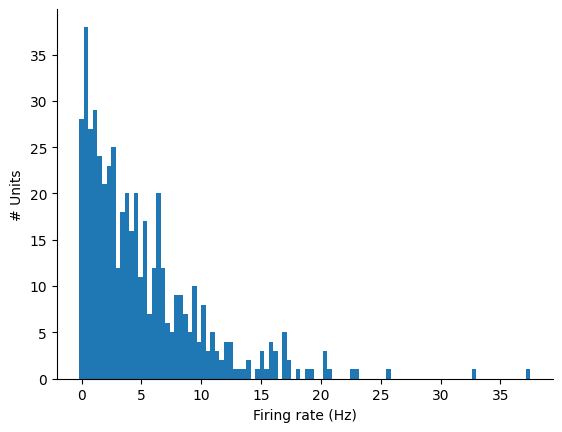

In [9]:

def plot_dataset_firings(ax):
    qm = analyzer_static.get_extension("quality_metrics").get_data()
    firing_rate = qm['firing_rate'].to_numpy()


    count, bins = np.histogram(firing_rate, bins=100)
    delta = bins[1] - bins[0]
    ax.bar(bins[:-1], count, width=delta,  color='C0')
    ax.set_xlabel("Firing rate (Hz)")
    ax.set_ylabel("# Units")
    # ax.set_yticks([])

    despine(ax)

with mpl.rc_context(myparams):
    fig, ax = plt.subplots()
    plot_dataset_firings(ax)



# plot snr

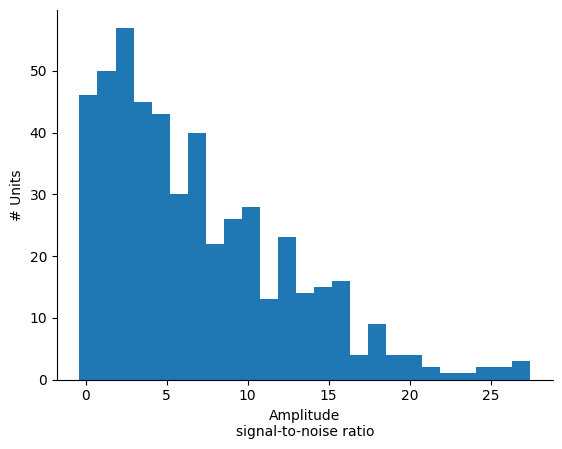

In [10]:

def plot_dataset_snr(ax):
    qm = analyzer_static.get_extension("quality_metrics").get_data()

    snr = qm['snr'].to_numpy()

    count, bins = np.histogram(snr, bins=25)
    delta = bins[1] - bins[0]
    ax.bar(bins[:-1], count, width=delta, color='C0')
    ax.set_xlabel("Amplitude\nsignal-to-noise ratio")
    ax.set_ylabel("# Units")
    # ax.set_yticks([])

    despine(ax)


with mpl.rc_context(myparams):
    fig, ax = plt.subplots()
    plot_dataset_snr(ax)


# similarity

In [11]:


analyzer_static.compute({"template_similarity": {'method':'l2'}})


/home/samuel.garcia/Documents/SpikeInterface/spikeinterface/src/spikeinterface/postprocessing/template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


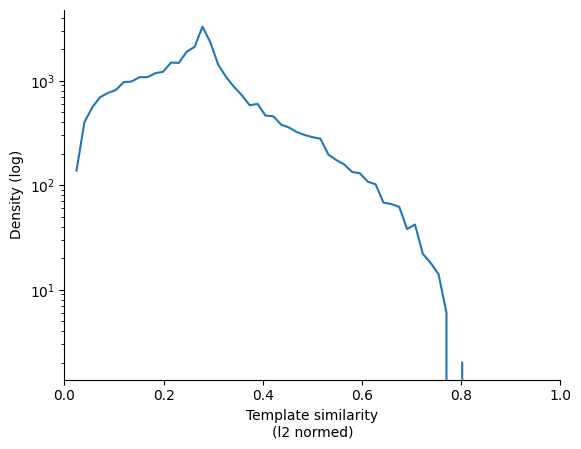

In [12]:

def plot_dataset_similarity(ax):
    analyzer_static.get_extension("template_similarity").params
    similarity = analyzer_static.get_extension("template_similarity").get_data()

    sim = similarity.flatten()
    sim = sim[sim!=1]
    sim = sim[sim!=0]


    count, bins = np.histogram(sim, bins=50)
    
    ax.semilogy(bins[:-1], count, )
    ax.set_xlim(0, 1)
    ax.set_xlabel('Template similarity\n(l2 normed)')
    ax.set_ylabel('Density (log)')

    despine(ax)

fig, ax = plt.subplots()
plot_dataset_similarity(ax)



In [13]:
myparams

{'axes.titlesize': 12,
 'axes.labelsize': 10,
 'lines.linewidth': 2,
 'lines.markersize': 10,
 'xtick.labelsize': 10,
 'ytick.labelsize': 10}

# plot templte motion

In [14]:
# GT templates for generated

# folder = base_path / "SimulatedDatasetsCache" / f"{dataset_name}_seed{seed}" / "drifting_recording"
folder = base_path / "SimulatedDatasetsCache" / f"{dataset_name}" / "drifting_recording"
rec = si.load(folder / "provenance.pkl", base_folder=folder)

gt_drifting_templates  = rec.drifting_templates
unit_ids = gt_drifting_templates.unit_ids

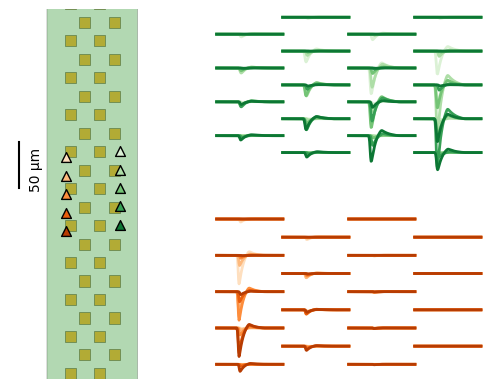

In [15]:
from spikeinterface.benchmark.benchmark_plot_tools import clean_axis

from matplotlib.gridspec import GridSpec



def plot_drift_waveforms_interpolation(ax0, axs1):

    sparsity = analyzer_static.sparsity
    static_templates = gt_drifting_templates.to_sparse(sparsity)
    static_templates

    unit_locations = extra_infos["unit_locations"]
    unit_locations

    displacement_indices = [0, 20, 40, 60, 80][::-1]
    # displacement_indices = [0, 30, 50, 80][::-1]
    n = len(displacement_indices)
    # fig, axs = plt.subplots(nrows=len(displacement_indices), figsize=(.8, 8))

    si.plot_probe_map(rec, ax=ax0)
    clean_axis(ax0)



    unit_indices = [100, 238]


    for u, unit_index in enumerate(unit_indices):
        # unit_index = 40
        unit_ids = gt_drifting_templates.unit_ids[unit_index:unit_index+1]


        cscale = [ 'Greens', 'Oranges',]
        cmap = plt.colormaps[cscale[u]].resampled(n+2)



        loc = unit_locations[unit_index, :2]
        # print(loc)
        for i, d in enumerate(displacement_indices):
            moved_loc = loc + gt_drifting_templates.displacements[d, :]
            ax0.scatter(moved_loc[:1],moved_loc[1:], s=50, marker='^', color=cmap(i+1), edgecolor='k')

        ax0.set_ylim(loc[1] - 200, loc[1] + 200)
        # clean_axis(ax0)
        ax0.set_xlabel('')
        ax0.set_ylabel('')

        if u == 0:
            y = loc[1]
            ax0.plot([-55, -55], [y, y + 50], color='k')
            ax0.text(-44, y, '50 μm', rotation=90)

        # axs = [fig.add_subplot(gs[i, -1]) for i in range(n)]
        # ax = fig.add_subplot(gs[u, 2:])

        ax = axs1[u]

        for i, d in enumerate(displacement_indices):

            # ax = axs[i]
            chan_mask = np.flatnonzero(sparsity.mask[unit_index])
            # dis = gt_drifting_templates.displacements[d, :]
            template = static_templates.select_units(unit_ids)
            moved_array = gt_drifting_templates.templates_array_moved[d, unit_index, :, :][:, chan_mask]
            template.templates_array = moved_array[None, :, :]
            

            si.plot_unit_templates(template, ax=ax, same_axis=True,
                                plot_legend=False,
                                # unit_colors = {unit_ids[0] : "m"},
                                unit_colors = {unit_ids[0] : cmap(i+1)},
                                abs_y_scale=0.6,
                                
                                backend="matplotlib")
        clean_axis(ax)
        ax.set_title('')


# fig = plt.figure(figsize=(4, 9), dpi=300)
fig = plt.figure()
gs = GridSpec(2, 5)
ax0 = fig.add_subplot(gs[:, :2])
axs1 = [fig.add_subplot(gs[u, 2:]) for u in range(2)]

plot_drift_waveforms_interpolation(ax0, axs1)



# fig.savefig('/home/samuel.garcia/figures_paper_v2/figure_generation_panelC.png')
# fig.savefig('/home/samuel.garcia/figures_paper_v2/figure_generation_panelC.pdf')

# up_template.


## la totale

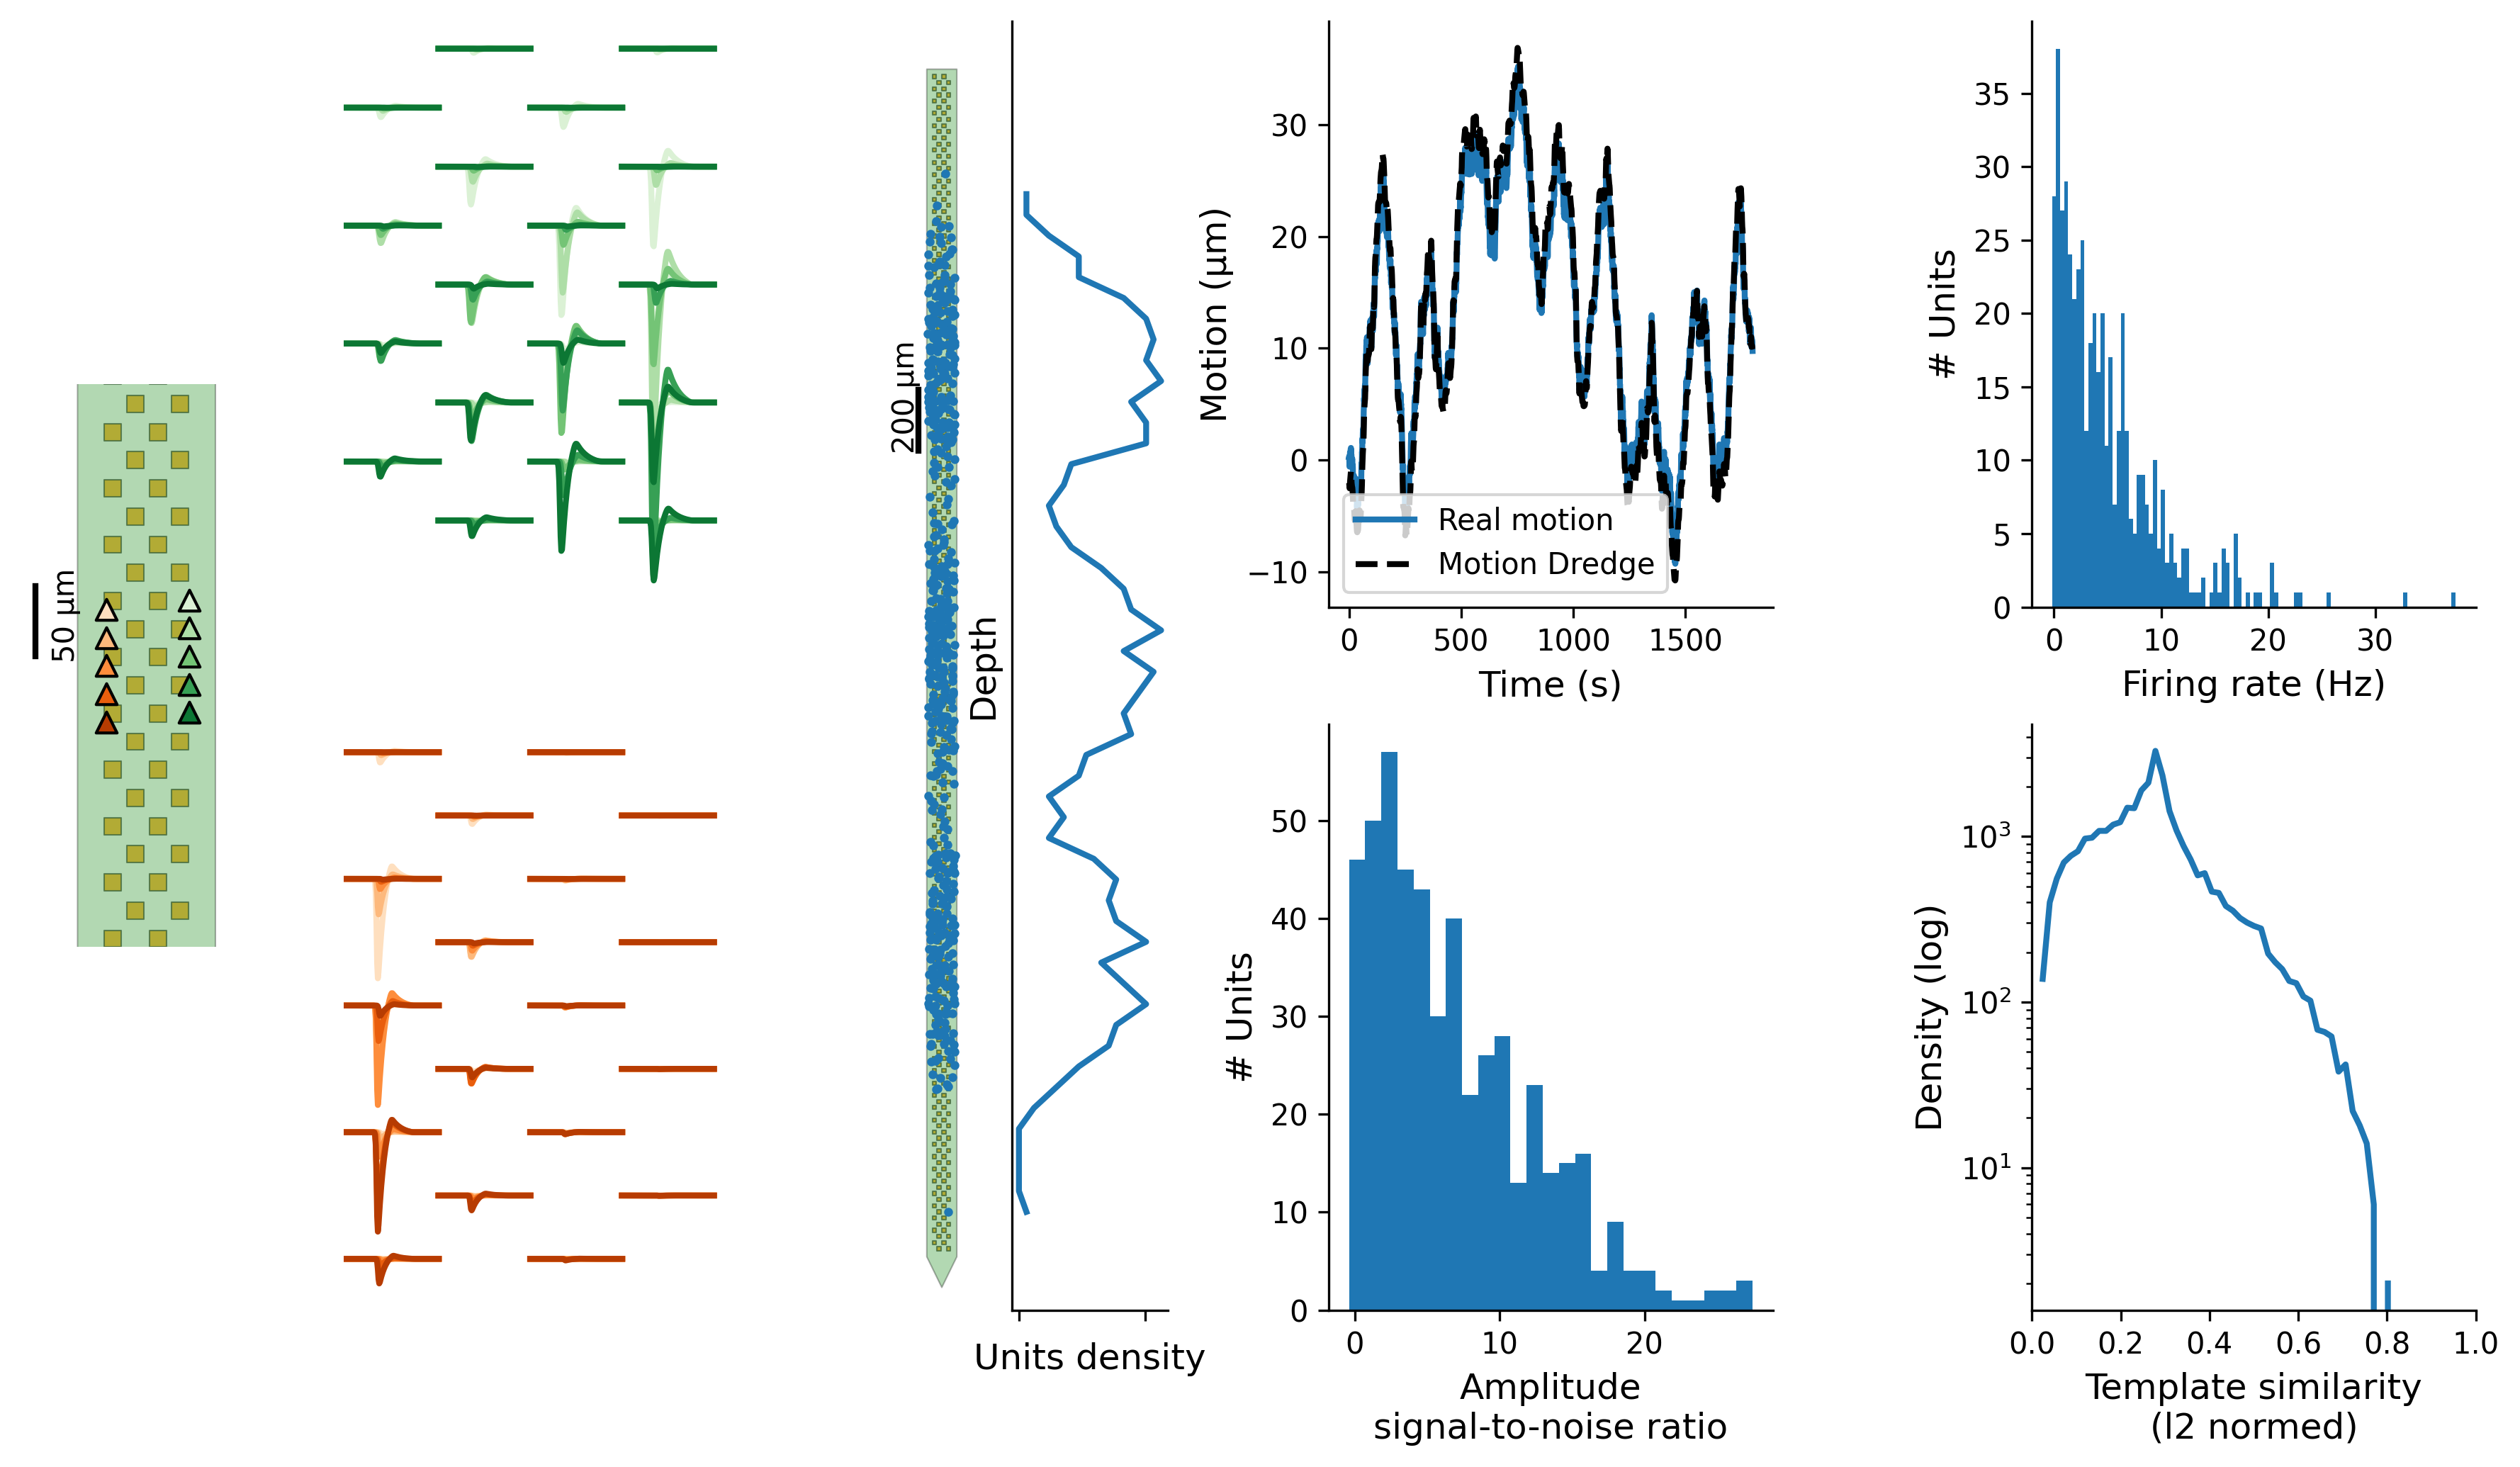

In [19]:
myparams = {
    'axes.titlesize' : 12,
    'axes.labelsize' : 12,
    'lines.linewidth' : 2,
    'lines.markersize' : 10,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10
}

with mpl.rc_context(myparams):

    fig = plt.figure(figsize=(12, 7), dpi=300)

    # fig = plt.figure()

    gs = GridSpec(1, 6, figure=fig)

    gs0 = GridSpecFromSubplotSpec(2, 5, subplot_spec=gs[0, 0:2])
    ax0 = fig.add_subplot(gs0[:, :2])
    axs0 = [fig.add_subplot(gs0[u, 2:]) for u in range(2)]

    gs1 = GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0, 2])
    ax1 = fig.add_subplot(gs1[0, 0:2])
    ax2 = fig.add_subplot(gs1[0, 2:5])


    gs2 = GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 3:6])
    ax3 = fig.add_subplot(gs2[0, 0])
    ax4 = fig.add_subplot(gs2[0, 1])
    ax5 = fig.add_subplot(gs2[1, 0])
    ax6 = fig.add_subplot(gs2[1, 1])

    # gs = GridSpec(2, 14, figure=fig, wspace=.5,)
    # ax1 = fig.add_subplot(gs[:,0])
    # ax2 = fig.add_subplot(gs[:, 1:4])
    # ax3 = fig.add_subplot(gs[0, 4:9])
    # ax4 = fig.add_subplot(gs[0, 9:14])
    # ax5 = fig.add_subplot(gs[1, 4:9])
    # ax6 = fig.add_subplot(gs[1, 9:14])


    plot_drift_waveforms_interpolation(ax0, axs0)

    plot_unit_locs_dist(ax1, ax2)
    # ax1.set_ylim(-200 , 4_000)
    # ax1.set_xlim(-150 , 120)
    # ax2.set_ylim(-200 , 4_000)


    plot_motion_dataset(ax3)
    plot_dataset_firings(ax4)
    plot_dataset_snr(ax5)
    plot_dataset_similarity(ax6)

    # fig.tight_layout(pad=1.08, h_pad=0.5)
    fig.tight_layout(h_pad=0)

    fig.savefig(figure_folder / 'figure_generation_panel.png')
    fig.savefig(figure_folder / 'figure_generation_panel.pdf')


    


## motion GT vs estimated

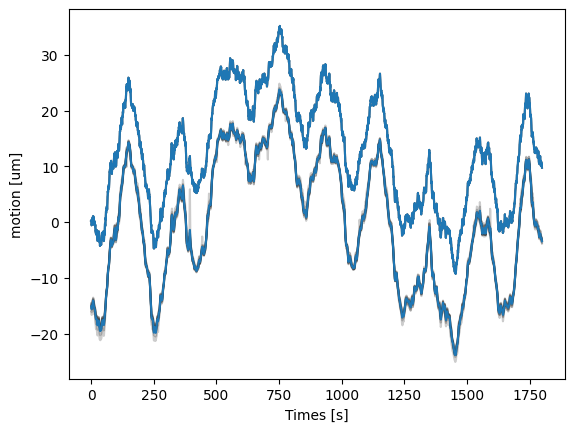

In [8]:
# check motion
import numpy as np
import spikeinterface.full as si
from configuration import base_path

from dataset import get_dataset
from spikeinterface.benchmark.benchmark_motion_estimation import get_gt_motion_from_unit_displacement
from spikeinterface.benchmark.benchmark_clustering import ClusteringStudy
import matplotlib.pyplot as plt

global_name = 'clustering_drifting'
# dataset_name = 'Neuronexus-32_50_300.s'
# dataset_name = 'Neuropixels-128_250_300.s'
# dataset_name = 'Neuropixels1-384_500_600.s'
dataset_name = 'Neuropixels1-384_500_1800.s'

motion_folder = base_path / global_name / dataset_name / 'motion'
# study_folder = base_path / global_name / dataset_name / 'study'



# study = ClusteringStudy(study_folder)


motion_info = motion = si.load_motion_info(motion_folder)
# drifting_rec, _ = study.datasets['corrected']
# si.plot_motion_info(motion_info, drifting_rec)
motion = motion_info['motion']



seed = 2205
extra_infos = get_dataset(dataset_name, with_extra_info=True, seed=seed)[-1]


# rec = drifting_rec
channel_locations = rec.get_channel_locations()
duration = rec.get_duration()


bin_s = 0.5
temporal_bins_s = np.arange(0, duration, bin_s)
spatial_bins_um = np.linspace(np.min(channel_locations[:, 1]), np.max(channel_locations[:, 1]), 4)


gt_motion = get_gt_motion_from_unit_displacement(
    extra_infos["unit_displacements"],
    extra_infos["displacement_sampling_frequency"],
    extra_infos["unit_locations"],
    temporal_bins_s,
    spatial_bins_um,
    direction_dim=1,
)


fig, ax = plt.subplots()
si.plot_motion(gt_motion, ax=ax)
si.plot_motion(motion, ax=ax)

# temporal_bins_s = motion.temporal_bins_s[0]
# offset = np.median(gt_motion.displacement[0][:, :]) - np.median(motion.displacement[0][:, :])
# displacement = motion.displacement[0] + offset
# ax.plot(temporal_bins_s, np.mean(displacement, axis=1), color="m", ls='--')


(3600, 4)